# Project Goal

# Build a business-focused sales analytics project for Wave Shoes that helps stakeholders:

# 1.Track revenue and profitability
# 2. Monitor product performance
# 3. Analyze customer and city trends
# 4. Compare online vs offline performance
# 5. Identify growth opportunities
# 6. Make strategic business decisions

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Visualization settings
plt.style.use('default')
sns.set_style('whitegrid')

# Loading Dataset

In [2]:
# Load Excel file
file_path = r"C:\Users\Admin\Documents\Deepak Documents\PROJECTS\Wavy  Shoes Sales Analysis\Fact_Sales.xlsx"

# Read data
sales_df = pd.read_excel(file_path)

# Preview dataset
sales_df.head()

,order_number,order_date,customer_name,city,state,order_type,product,category,cost_per_unit,selling_price_per_unit,quantity,cost,sales_amount,profit,profit_margin_%
0,Or_1001,2020-01-01,Rajesh Shinde,Mumbai,Maharashtra,Offline Store,Single Monk,Casual,4500,6000,2,9000,12000,3000,25.00
1,Or_1002,2020-01-01,Rahul Kale,Delhi,Delhi,Offline Store,Single Monk,Casual,4500,6000,2,9000,12000,3000,25.00
2,Or_1003,2020-01-01,Mohammed Abdul Kaleem,Bangalore,Karnataka,Offline Store,Single Monk,Casual,4500,6000,1,4500,6000,1500,25.00
3,Or_1004,2020-01-01,Chandrakant Soni,Hyderabad,Andhra Pradesh,Offline Store,Single Monk,Casual,4500,6000,4,18000,24000,6000,25.00
4,Or_1005,2020-01-01,Rohan Kale,Ahmedabad,Gujarat,Offline Store,Loafers,Formal,3700,4450,2,7400,8900,1500,16.85


# Dataset Information

In [3]:
# Shape of dataset
print("Rows and Columns:", sales_df.shape)

# Dataset info
sales_df.info()

Rows and Columns: (7826, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7826 entries, 0 to 7825
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_number            7826 non-null   object        
 1   order_date              7826 non-null   datetime64[ns]
 2   customer_name           7826 non-null   object        
 3   city                    7826 non-null   object        
 4   state                   7826 non-null   object        
 5   order_type              7826 non-null   object        
 6   product                 7826 non-null   object        
 7   category                7826 non-null   object        
 8   cost_per_unit           7826 non-null   int64         
 9   selling_price_per_unit  7826 non-null   int64         
 10  quantity                7826 non-null   int64         
 11  cost                    7826 non-null   int64         
 12  sales_amount       

# Check Missing Values

In [4]:
# Missing values
sales_df.isnull().sum()

order_number              0
order_date                0
customer_name             0
city                      0
state                     0
order_type                0
product                   0
category                  0
cost_per_unit             0
selling_price_per_unit    0
quantity                  0
cost                      0
sales_amount              0
profit                    0
profit_margin_%           0
dtype: int64

# Convert Date Column

In [5]:
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])

# Extract date features
sales_df['Year'] = sales_df['order_date'].dt.year
sales_df['Month'] = sales_df['order_date'].dt.month_name()
sales_df['Month_Number'] = sales_df['order_date'].dt.month
sales_df['Quarter'] = sales_df['order_date'].dt.quarter
sales_df['Weekday'] = sales_df['order_date'].dt.day_name()

sales_df.head()

,order_number,order_date,customer_name,city,state,order_type,product,category,cost_per_unit,selling_price_per_unit,quantity,cost,sales_amount,profit,profit_margin_%,Year,Month,Month_Number,Quarter,Weekday
0,Or_1001,2020-01-01,Rajesh Shinde,Mumbai,Maharashtra,Offline Store,Single Monk,Casual,4500,6000,2,9000,12000,3000,25.00,2020,January,1,1,Wednesday
1,Or_1002,2020-01-01,Rahul Kale,Delhi,Delhi,Offline Store,Single Monk,Casual,4500,6000,2,9000,12000,3000,25.00,2020,January,1,1,Wednesday
2,Or_1003,2020-01-01,Mohammed Abdul Kaleem,Bangalore,Karnataka,Offline Store,Single Monk,Casual,4500,6000,1,4500,6000,1500,25.00,2020,January,1,1,Wednesday
3,Or_1004,2020-01-01,Chandrakant Soni,Hyderabad,Andhra Pradesh,Offline Store,Single Monk,Casual,4500,6000,4,18000,24000,6000,25.00,2020,January,1,1,Wednesday
4,Or_1005,2020-01-01,Rohan Kale,Ahmedabad,Gujarat,Offline Store,Loafers,Formal,3700,4450,2,7400,8900,1500,16.85,2020,January,1,1,Wednesday


# Business KPIs

In [6]:
# KPI calculations
Total_Sales = sales_df['sales_amount'].sum()
Total_Profit = sales_df['profit'].sum()
Total_Orders = sales_df['order_number'].nunique()
Total_Customers = sales_df['customer_name'].nunique()
Total_Quantity = sales_df['quantity'].sum()
Profit_Margin = (Total_Profit / Total_Sales) * 100

print(f"Total Sales: ₹{Total_Sales:,.0f}")
print(f"Total Profit: ₹{Total_Profit:,.0f}")
print(f"Total Orders: {Total_Orders}")
print(f"Total Customers: {Total_Customers}")
print(f"Total Quantity Sold: {Total_Quantity}")
print(f"Profit Margin: {Profit_Margin:.2f}%")

Total Sales: ₹113,328,710
Total Profit: ₹25,381,110
Total Orders: 7826
Total Customers: 44
Total Quantity Sold: 24048
Profit Margin: 22.40%


# Monthly Revenue Trend
Business Insight

Track how revenue changes month-over-month.

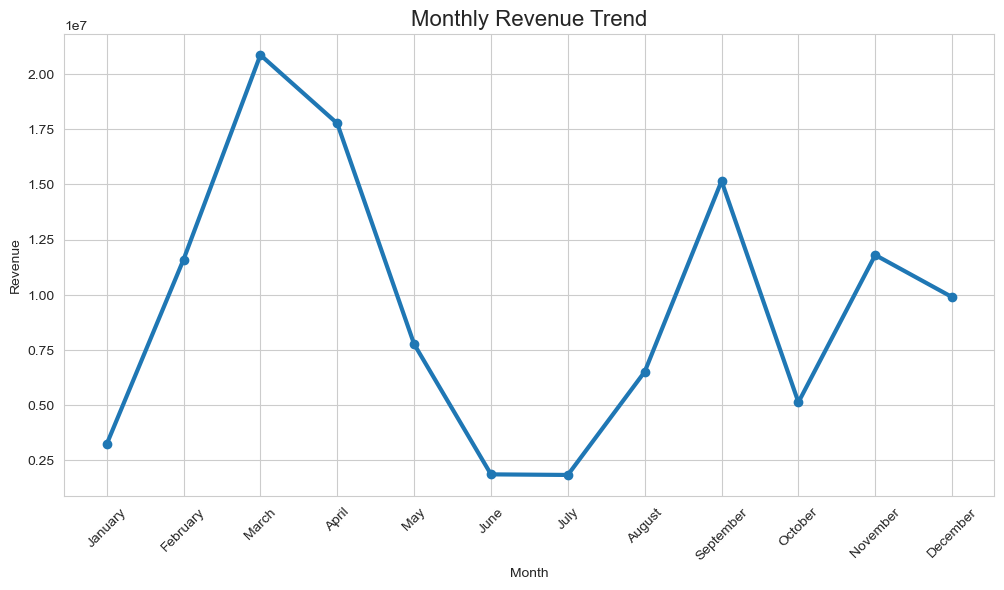

In [7]:
monthly_sales = sales_df.groupby(['Month_Number', 'Month'])['sales_amount'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('Month_Number')

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['sales_amount'], marker='o', linewidth=3)

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Monthly Profit Trend

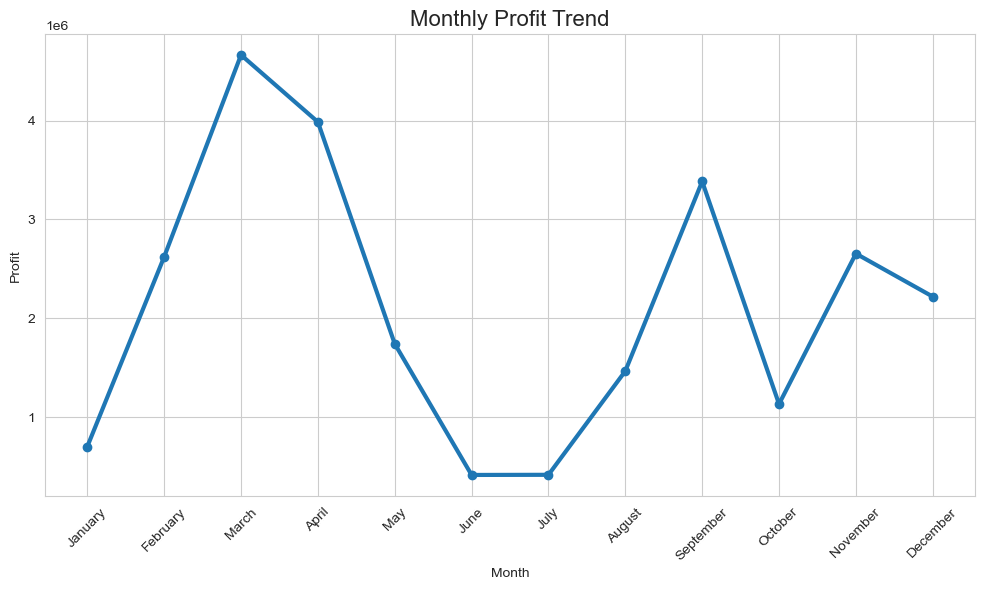

In [8]:
monthly_profit = sales_df.groupby(['Month_Number', 'Month'])['profit'].sum().reset_index()
monthly_profit = monthly_profit.sort_values('Month_Number')

plt.figure(figsize=(12,6))
plt.plot(monthly_profit['Month'], monthly_profit['profit'], marker='o', linewidth=3)

plt.title('Monthly Profit Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

# Sales vs Profit Comparison
Business Insight

Understand whether higher sales generate proportional profit.

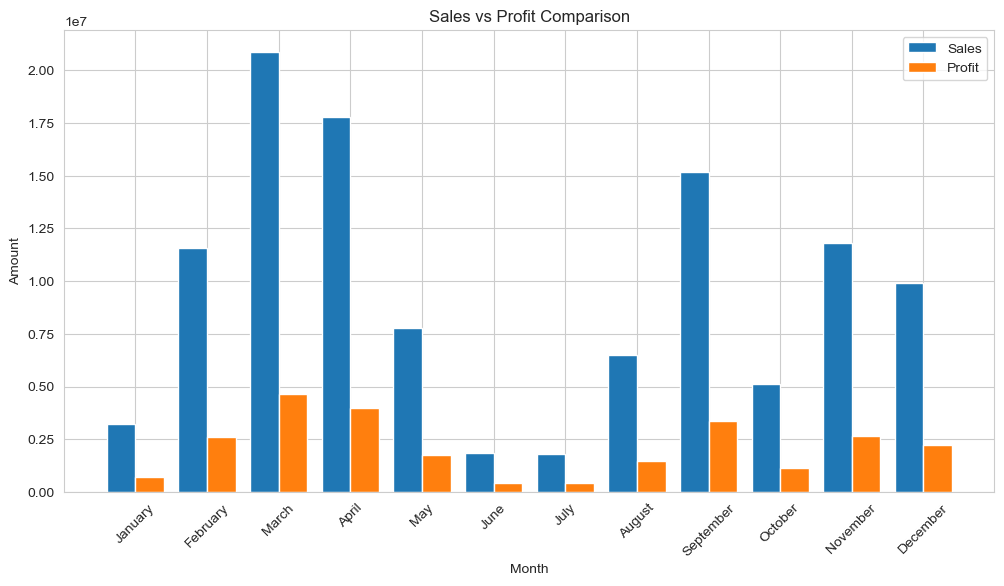

In [9]:
monthly_metrics = sales_df.groupby(['Month_Number', 'Month'])[['sales_amount', 'profit']].sum().reset_index()
monthly_metrics = monthly_metrics.sort_values('Month_Number')

plt.figure(figsize=(12,6))

x = np.arange(len(monthly_metrics))
width = 0.4

plt.bar(x - width/2, monthly_metrics['sales_amount'], width=width, label='Sales')
plt.bar(x + width/2, monthly_metrics['profit'], width=width, label='Profit')

plt.xticks(x, monthly_metrics['Month'], rotation=45)
plt.title('Sales vs Profit Comparison')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()

plt.show()

# Top Selling Products
Business Insight

Identify products driving maximum revenue.

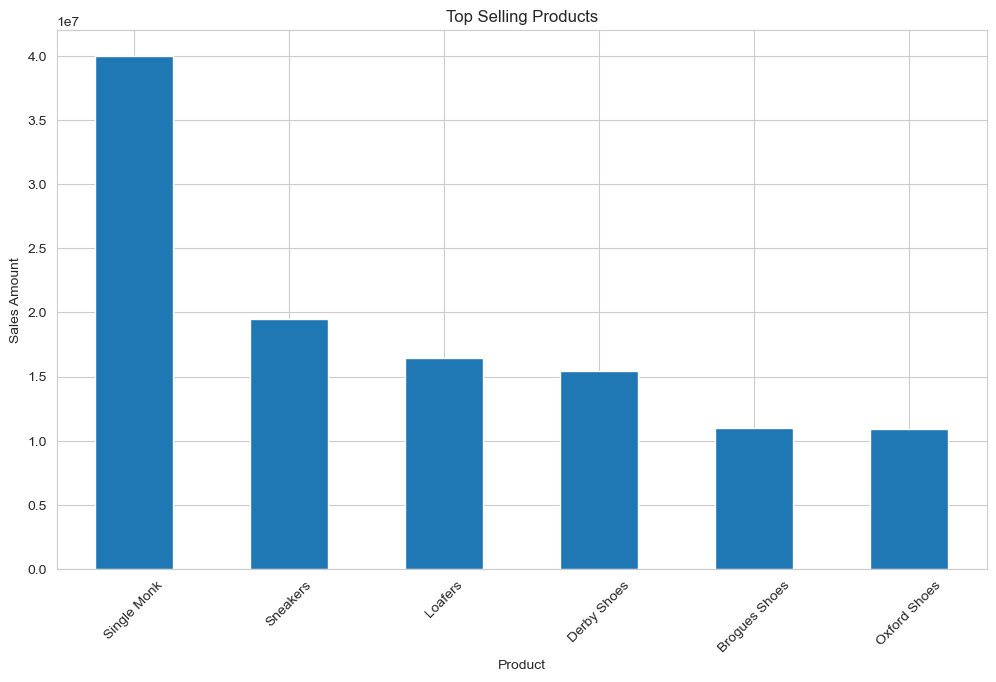

In [10]:
product_sales = sales_df.groupby('product')['sales_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,7))
product_sales.plot(kind='bar')

plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

# Most Profitable Products

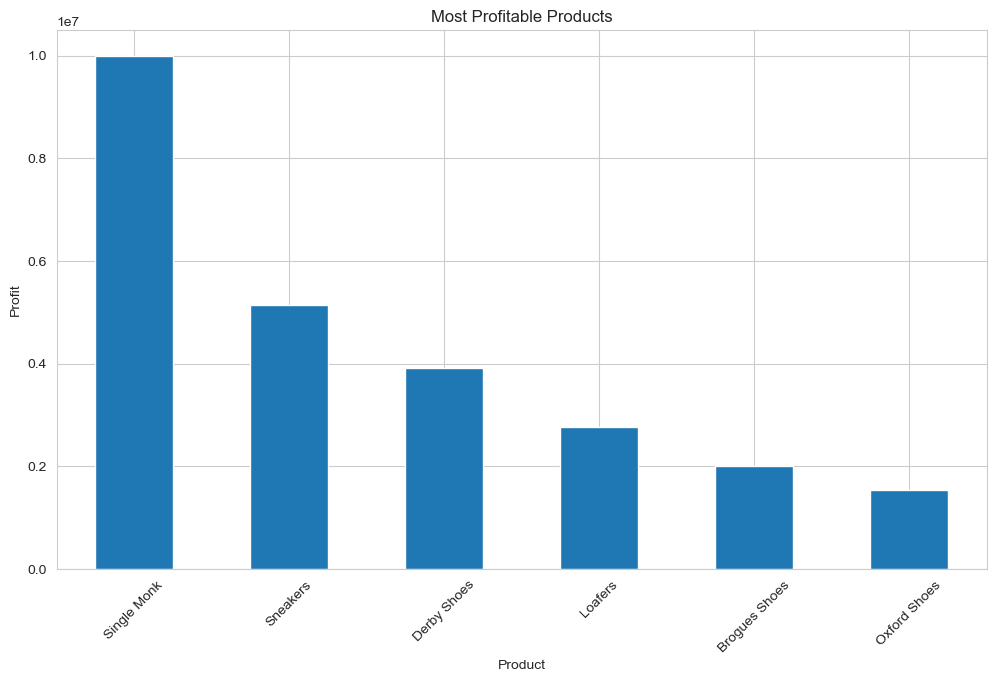

In [11]:
product_profit = sales_df.groupby('product')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,7))
product_profit.plot(kind='bar')

plt.title('Most Profitable Products')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

# Category Performance Analysis
Business Insight

Analyze Casual vs Formal product performance.

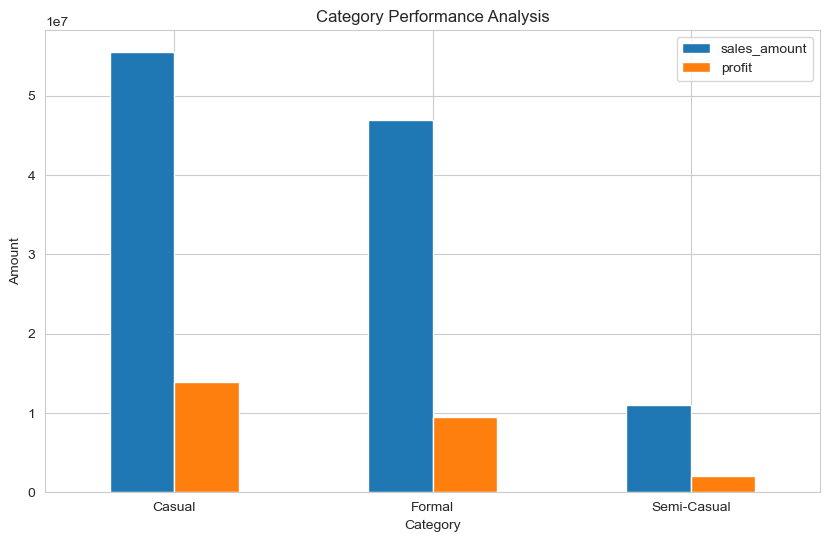

In [12]:
category_analysis = sales_df.groupby('category')[['sales_amount', 'profit']].sum()

category_analysis.plot(kind='bar', figsize=(10,6))

plt.title('Category Performance Analysis')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

# Online vs Offline Sales
Business Insight

Compare sales channels

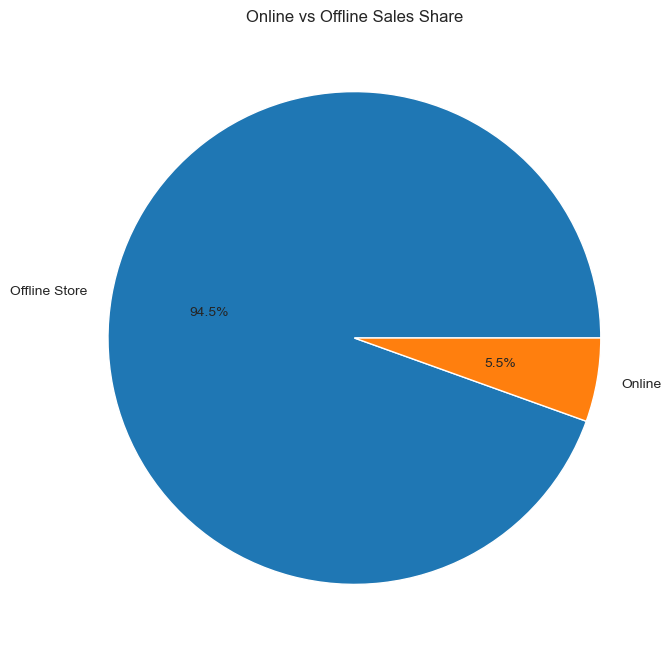

In [13]:
channel_sales = sales_df.groupby('order_type')['sales_amount'].sum()

plt.figure(figsize=(8,8))
plt.pie(channel_sales, labels=channel_sales.index, autopct='%1.1f%%')

plt.title('Online vs Offline Sales Share')
plt.show()

# Online vs Offline Profit

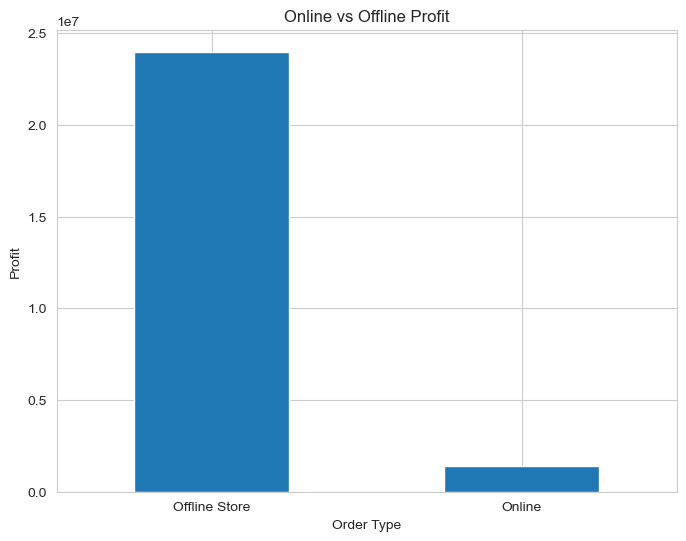

In [14]:
channel_profit = sales_df.groupby('order_type')['profit'].sum()

plt.figure(figsize=(8,6))
channel_profit.plot(kind='bar')

plt.title('Online vs Offline Profit')
plt.xlabel('Order Type')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

# Top 10 Customers
Business Insight

Find highest revenue generating customers.

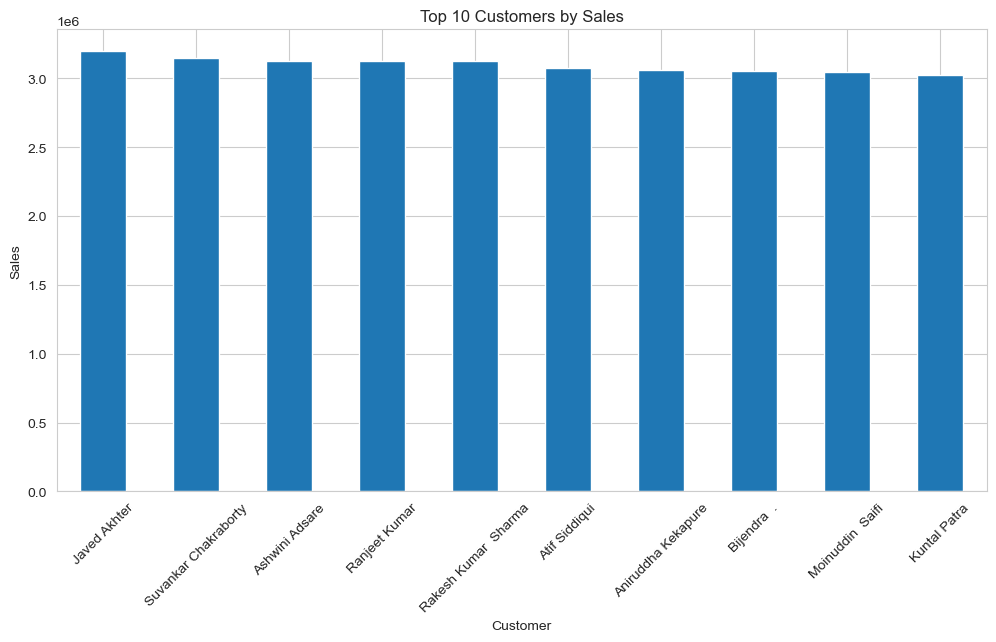

In [15]:
customer_sales = sales_df.groupby('customer_name')['sales_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
customer_sales.plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

# Top Cities by Revenue
Business Insight

Identify strongest performing cities.

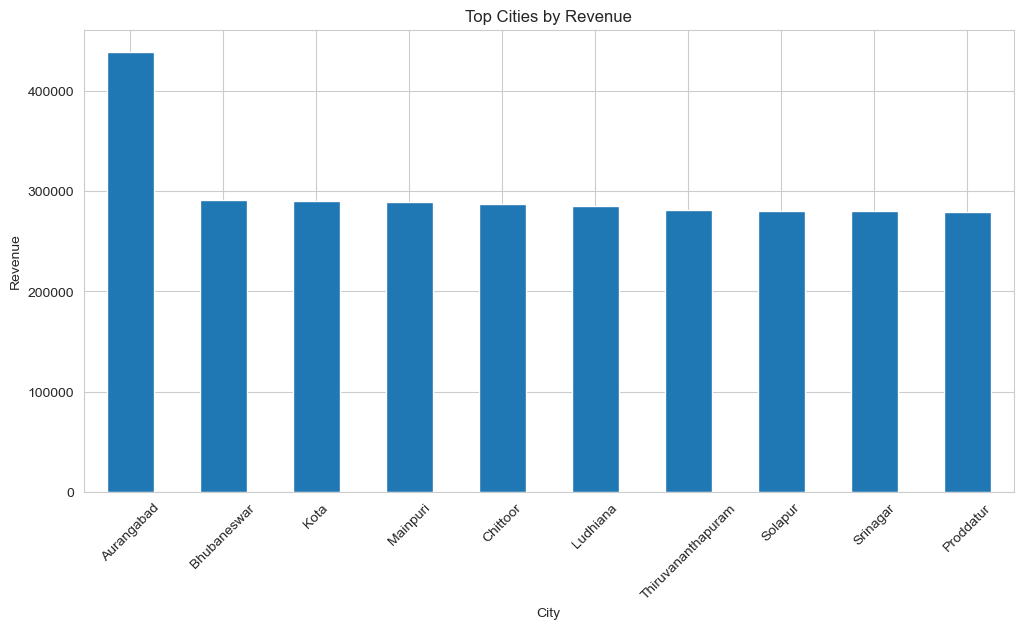

In [16]:
city_sales = sales_df.groupby('city')['sales_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_sales.plot(kind='bar')

plt.title('Top Cities by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Top Cities by Profit

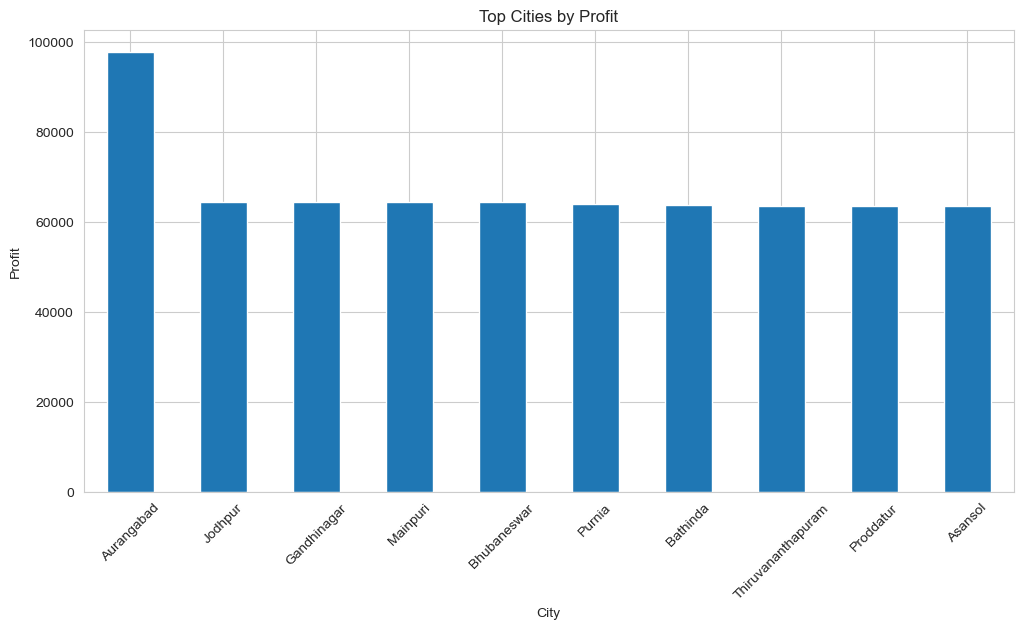

In [17]:
city_profit = sales_df.groupby('city')['profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_profit.plot(kind='bar')

plt.title('Top Cities by Profit')
plt.xlabel('City')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

# Profit Margin Analysis
Business Insight

Check which products have strong margins.

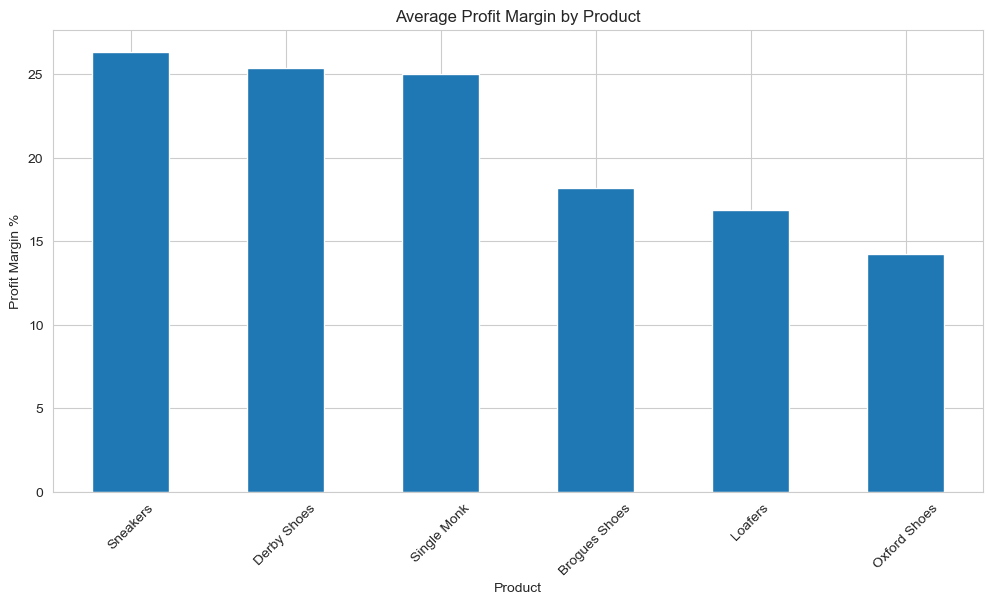

In [19]:
margin_analysis = sales_df.groupby('product')['profit_margin_%'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
margin_analysis.plot(kind='bar')

plt.title('Average Profit Margin by Product')
plt.xlabel('Product')
plt.ylabel('Profit Margin %')
plt.xticks(rotation=45)
plt.show()

# Sales Heatmap
Business Insight

Understand weekday-wise sales patterns.

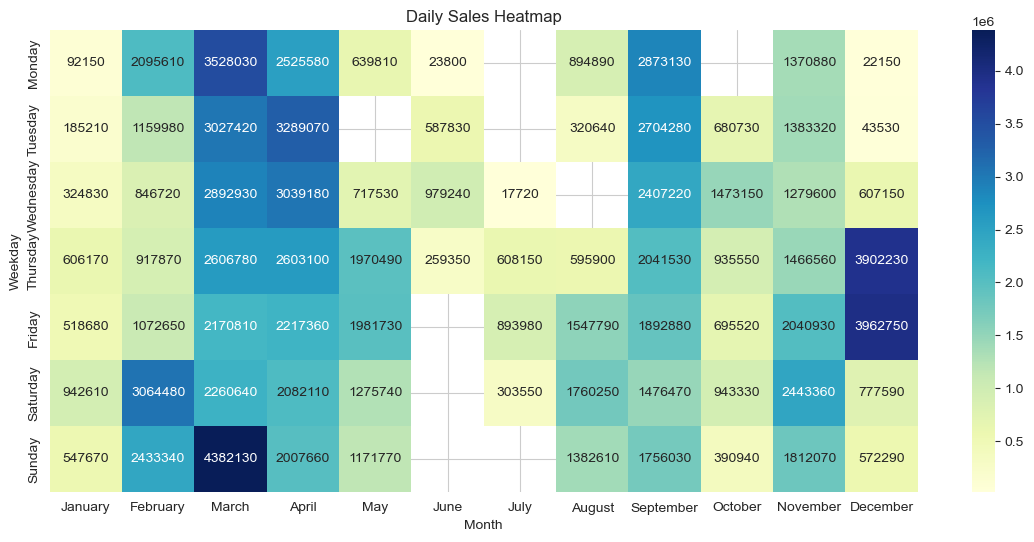

In [21]:
heatmap_data = sales_df.pivot_table(
    values='sales_amount',
    index='Weekday',
    columns='Month',
    aggfunc='sum'
)

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

heatmap_data = heatmap_data.reindex(columns=month_order)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')

plt.title('Daily Sales Heatmap')
plt.show()

# Quantity Sold Analysis

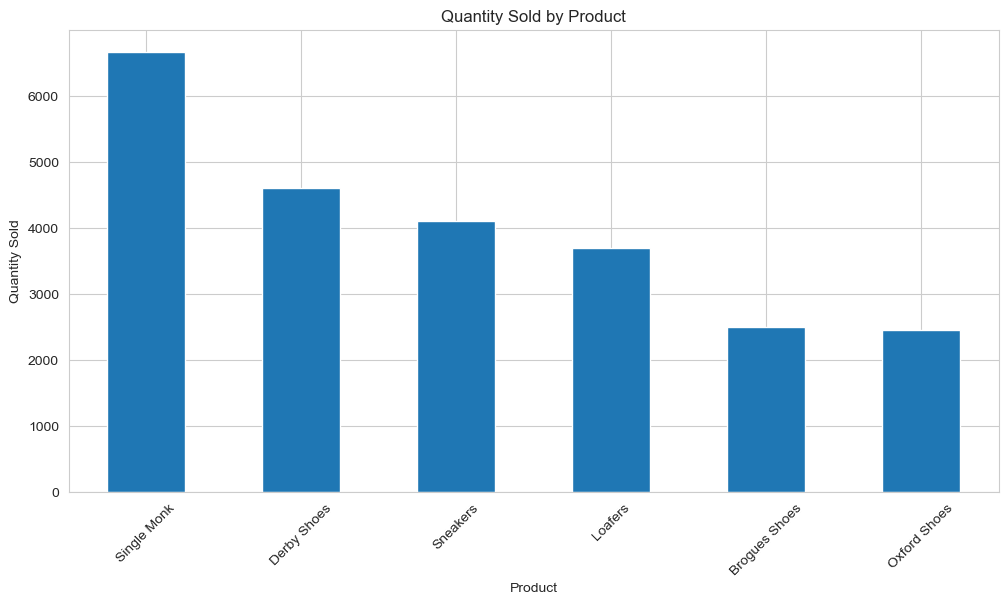

In [22]:
quantity_analysis = sales_df.groupby('product')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
quantity_analysis.plot(kind='bar')

plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

# State-wise Revenue Analysis
Business Insight

Find states contributing maximum sales.

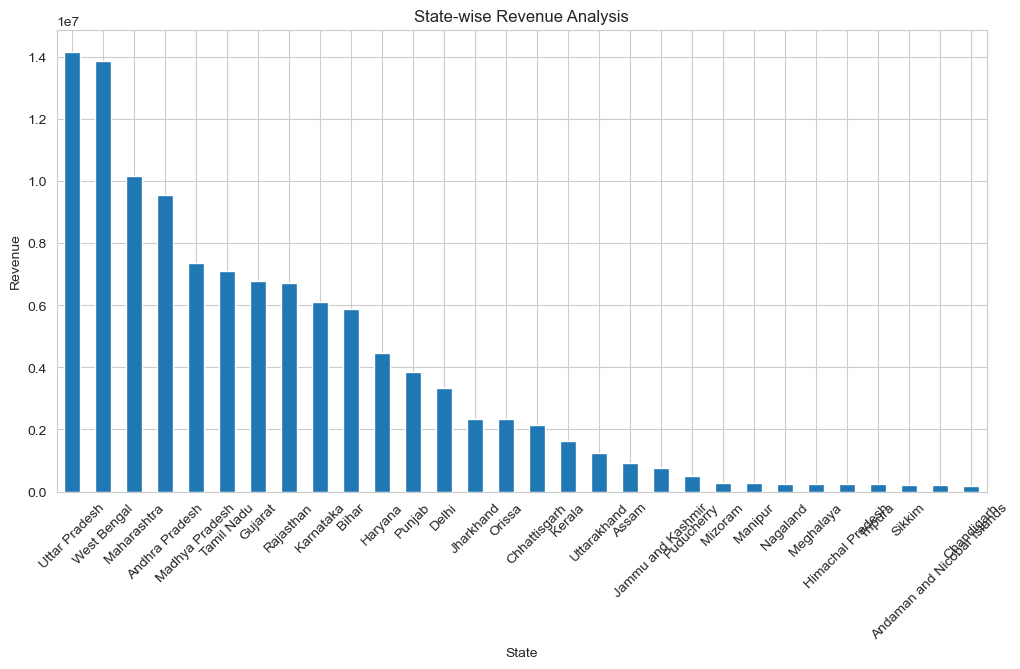

In [23]:
state_sales = sales_df.groupby('state')['sales_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_sales.plot(kind='bar')

plt.title('State-wise Revenue Analysis')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Correlation Analysis
Business Insight

Understand relationships between metrics.

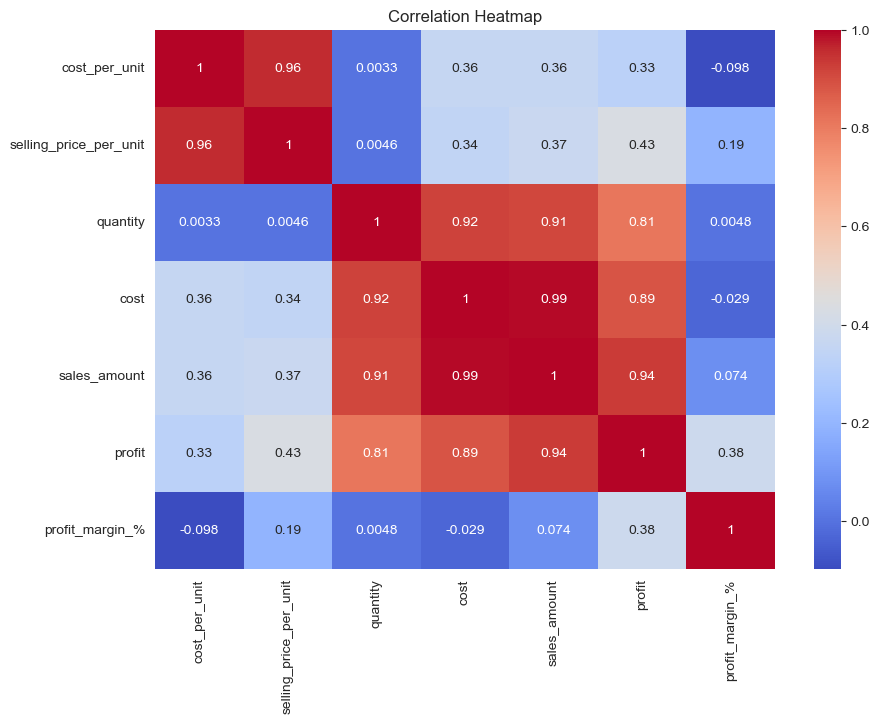

In [24]:
corr_df = sales_df[[
    'cost_per_unit',
    'selling_price_per_unit',
    'quantity',
    'cost',
    'sales_amount',
    'profit',
    'profit_margin_%'
]]

plt.figure(figsize=(10,7))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# Best Performing Products Table

In [25]:
best_products = sales_df.groupby('product').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'quantity':'sum',
    'profit_margin_%':'mean'
}).sort_values(by='sales_amount', ascending=False)

best_products

,sales_amount,profit,quantity,profit_margin_%
product,,,,
Single Monk,39996000,9999000,6666,25.00
Sneakers,19513000,5135000,4108,26.32
Loafers,16473900,2776500,3702,16.85
Derby Shoes,15456900,3921900,4614,25.37
Brogues Shoes,11004400,2000800,2501,18.18
Oxford Shoes,10884510,1547910,2457,14.22


# Business Insights Summary

In [26]:
print("BUSINESS INSIGHTS")
print("="*50)

# Best product
best_product = sales_df.groupby('product')['sales_amount'].sum().idxmax()
print(f"Top Revenue Generating Product: {best_product}")

# Best city
best_city = sales_df.groupby('city')['sales_amount'].sum().idxmax()
print(f"Top Performing City: {best_city}")

# Best channel
best_channel = sales_df.groupby('order_type')['sales_amount'].sum().idxmax()
print(f"Best Sales Channel: {best_channel}")

# Highest profit product
best_profit_product = sales_df.groupby('product')['profit'].sum().idxmax()
print(f"Most Profitable Product: {best_profit_product}")

# Highest margin product
best_margin_product = sales_df.groupby('product')['profit_margin_%'].mean().idxmax()
print(f"Highest Margin Product: {best_margin_product}")

BUSINESS INSIGHTS
Top Revenue Generating Product: Single Monk
Top Performing City: Aurangabad
Best Sales Channel: Offline Store
Most Profitable Product: Single Monk
Highest Margin Product: Sneakers
